In [4]:
from google.colab import files
files.upload()  # kaggle.json upload karo yahan

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"wisdomsiddharth","key":"KGAT_22ca46303abb10b37bd814f302f3d47e"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d anishsarkar22/asvpoof-2019-dataset-la
!unzip asvpoof-2019-dataset-la.zip

Streaming output truncated to the last 5000 lines.
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8184716.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8184748.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8185024.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8185303.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8185322.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8185499.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8185768.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8186588.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8186635.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8188113.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8188211.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8189307.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8189555.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8189595.flac  
  inflating: LA/ASVspoof2019_LA_train/flac/LA_T_8189612.flac  
  in

In [8]:
import os
import numpy as np
import librosa
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("All libraries imported successfully")

All libraries imported successfully


In [9]:
# Load protocol/label files
train_protocol = pd.read_csv(
    'LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt',
    sep=' ', header=None,
    names=['speaker', 'file', 'env', 'attack', 'label']
)

print(train_protocol.head())
print(train_protocol['label'].value_counts())

   speaker          file env attack     label
0  LA_0079  LA_T_1138215   -      -  bonafide
1  LA_0079  LA_T_1271820   -      -  bonafide
2  LA_0079  LA_T_1272637   -      -  bonafide
3  LA_0079  LA_T_1276960   -      -  bonafide
4  LA_0079  LA_T_1341447   -      -  bonafide
label
spoof       22800
bonafide     2580
Name: count, dtype: int64


In [10]:
# Extract MFCC features
def extract_mfcc(file_path, n_mfcc=40, max_len=200):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] < max_len:
            mfcc = np.pad(mfcc, ((0,0),(0, max_len - mfcc.shape[1])))
        else:
            mfcc = mfcc[:, :max_len]
        return mfcc.T
    except:
        return None

# Use subset for speed (full dataset = very slow on Colab)
subset = train_protocol.sample(n=2000, random_state=42)
print(subset['label'].value_counts())

label
spoof       1799
bonafide     201
Name: count, dtype: int64


In [11]:
X, y = [], []
train_audio_path = 'LA/ASVspoof2019_LA_train/flac/'

for _, row in subset.iterrows():
    path = os.path.join(train_audio_path, row['file'] + '.flac')
    mfcc = extract_mfcc(path)
    if mfcc is not None:
        X.append(mfcc)
        y.append(row['label'])

X = np.array(X)
y = np.array(y)
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (2000, 200, 40), y shape: (2000,)


In [12]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {le.classes_}")

Train: (1600, 200, 40), Test: (400, 200, 40)
Classes: ['bonafide' 'spoof']


In [13]:
# Build LSTM Model
model = Sequential([
    LSTM(128, input_shape=(200, 40), return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 200, 128)       │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,049 (539.25 KB)

 Trainable params: 138,049 (539.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 352ms/step - accuracy: 0.8913 - loss: 0.3854 - val_accuracy: 0.9000 - val_loss: 0.3272
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 367ms/step - accuracy: 0.8994 - loss: 0.3291 - val_accuracy: 0.9000 - val_loss: 0.3289
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 347ms/step - accuracy: 0.8994 - loss: 0.3246 - val_accuracy: 0.9000 - val_loss: 0.3230
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 365ms/step - accuracy: 0.8994 - loss: 0.3227 - val_accuracy: 0.9000 - val_loss: 0.3247
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 350ms/step - accuracy: 0.8994 - loss: 0.3245 - val_accuracy: 0.9000 - val_loss: 0.3241
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 440ms/step - accuracy: 0.8994 - loss: 0.3273 - val_accuracy: 0.9000 - val_loss: 0.3230
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 341ms/step - accuracy: 0.8994 - loss: 0.3272 - val_accuracy: 0.9000 - val_loss: 0.3269
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 355ms/step - accuracy: 0.8994 - loss: 0.3234 - val_accu

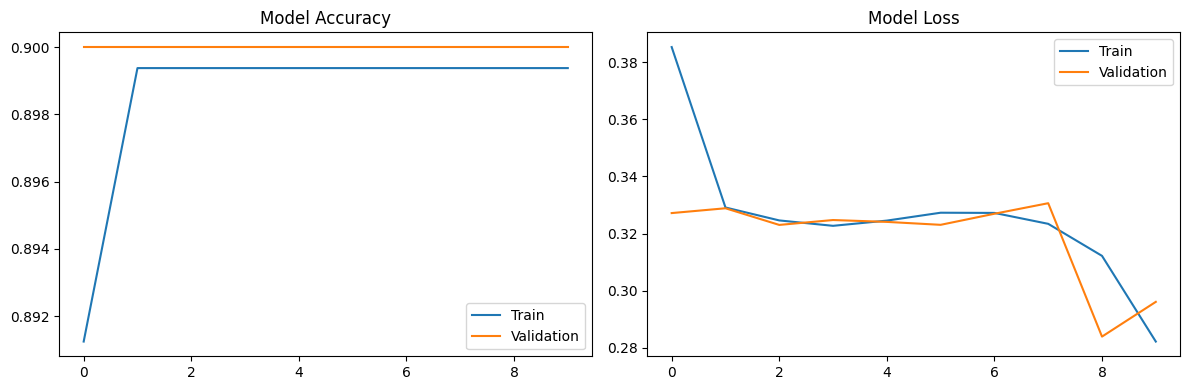

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 523ms/step
              precision    recall  f1-score   support

    bonafide       0.00      0.00      0.00        40
       spoof       0.90      1.00      0.95       360

    accuracy                           0.90       400
   macro avg       0.45      0.50      0.47       400
weighted avg       0.81      0.90      0.85       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


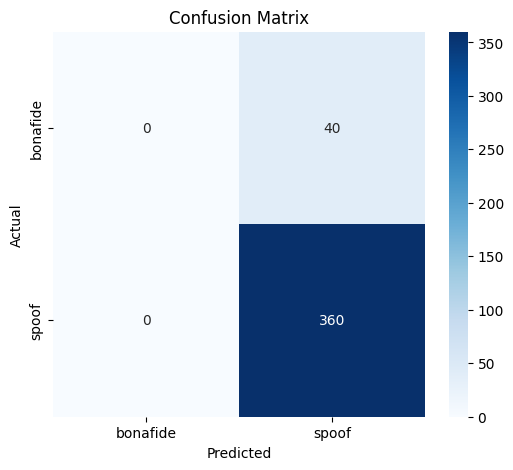

In [16]:
# Evaluation
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [17]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Rebuild model
model2 = Sequential([
    tf.keras.layers.Input(shape=(200, 40)),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(4.968944099378882), 1: np.float64(0.5559416261292565)}
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 355ms/step - accuracy: 0.2994 - loss: 0.6880 - val_accuracy: 0.1825 - val_loss: 0.6757
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 367ms/step - accuracy: 0.2081 - loss: 0.6814 - val_accuracy: 0.1875 - val_loss: 0.7149
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step - accuracy: 0.2206 - loss: 0.6783 - val_accuracy: 0.2250 - val_loss: 0.6797
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 358ms/step - accuracy: 0.2313 - loss: 0.6748 - val_accuracy: 0.2275 - val_loss: 0.6748
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 343ms/step - accuracy: 0.2962 - loss: 0.6785 - val_accuracy: 0.2225 - val_loss: 0.6969
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 386ms/step - accuracy: 0.2469 - loss: 0.6723 - val_accuracy: 0.2450 - val_loss: 0.7017
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 342ms/step - accuracy: 0.5200 - loss: 0.6639 - val_accuracy: 0.2275 - val_loss: 0.6826
Epoch 8/15
5

In [18]:
# Take equal samples of both classes
bonafide_df = train_protocol[train_protocol['label'] == 'bonafide']
spoof_df = train_protocol[train_protocol['label'] == 'spoof'].sample(n=len(bonafide_df), random_state=42)
balanced_df = pd.concat([bonafide_df, spoof_df]).sample(frac=1, random_state=42)

print(balanced_df['label'].value_counts())

label
bonafide    2580
spoof       2580
Name: count, dtype: int64


In [19]:
X2, y2 = [], []

for _, row in balanced_df.iterrows():
    path = os.path.join(train_audio_path, row['file'] + '.flac')
    mfcc = extract_mfcc(path)
    if mfcc is not None:
        X2.append(mfcc)
        y2.append(row['label'])

X2 = np.array(X2)
y2 = np.array(y2)
print(f"X2 shape: {X2.shape}, y2 shape: {y2.shape}")

X2 shape: (5160, 200, 40), y2 shape: (5160,)


In [20]:
le2 = LabelEncoder()
y2_encoded = le2.fit_transform(y2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2_encoded, test_size=0.2, random_state=42, stratify=y2_encoded
)

model3 = Sequential([
    tf.keras.layers.Input(shape=(200, 40)),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history3 = model3.fit(
    X2_train, y2_train,
    epochs=15,
    batch_size=32,
    validation_data=(X2_test, y2_test),
    verbose=1
)

Epoch 1/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 60s 396ms/step - accuracy: 0.5620 - loss: 0.6689 - val_accuracy: 0.7762 - val_loss: 0.5025
Epoch 2/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 49s 377ms/step - accuracy: 0.6994 - loss: 0.5777 - val_accuracy: 0.6521 - val_loss: 0.5896
Epoch 3/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 48s 371ms/step - accuracy: 0.7599 - loss: 0.5115 - val_accuracy: 0.7936 - val_loss: 0.4591
Epoch 4/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 365ms/step - accuracy: 0.7900 - loss: 0.4766 - val_accuracy: 0.7800 - val_loss: 0.4851
Epoch 5/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 49s 383ms/step - accuracy: 0.7917 - loss: 0.4824 - val_accuracy: 0.8198 - val_loss: 0.4640
Epoch 6/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 363ms/step - accuracy: 0.8144 - loss: 0.4617 - val_accuracy: 0.7965 - val_loss: 0.4581
Epoch 7/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 46s 354ms/step - accuracy: 0.7277 - loss: 0.5379 - val_accuracy: 0.5407 - val_loss: 0.6777
Epoch 8/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 83s 366ms/step - accuracy: 0.5359 - loss: 0

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step
              precision    recall  f1-score   support

    bonafide       0.85      0.92      0.88       516
       spoof       0.91      0.84      0.88       516

    accuracy                           0.88      1032
   macro avg       0.88      0.88      0.88      1032
weighted avg       0.88      0.88      0.88      1032



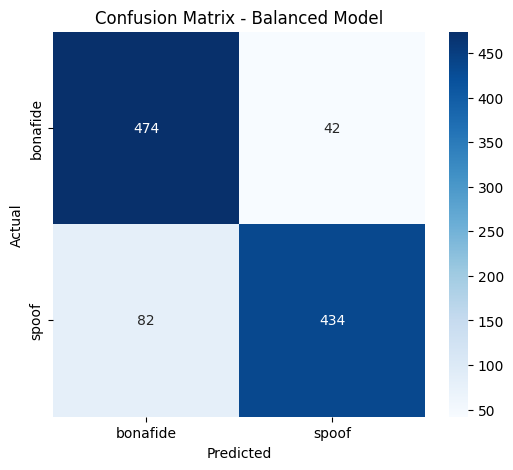

In [21]:
y2_pred = (model3.predict(X2_test) > 0.5).astype(int).flatten()

print(classification_report(y2_test, y2_pred, target_names=le2.classes_))

cm2 = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le2.classes_, yticklabels=le2.classes_)
plt.title('Confusion Matrix - Balanced Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_balanced.png', dpi=150)
plt.show()

Model saved.


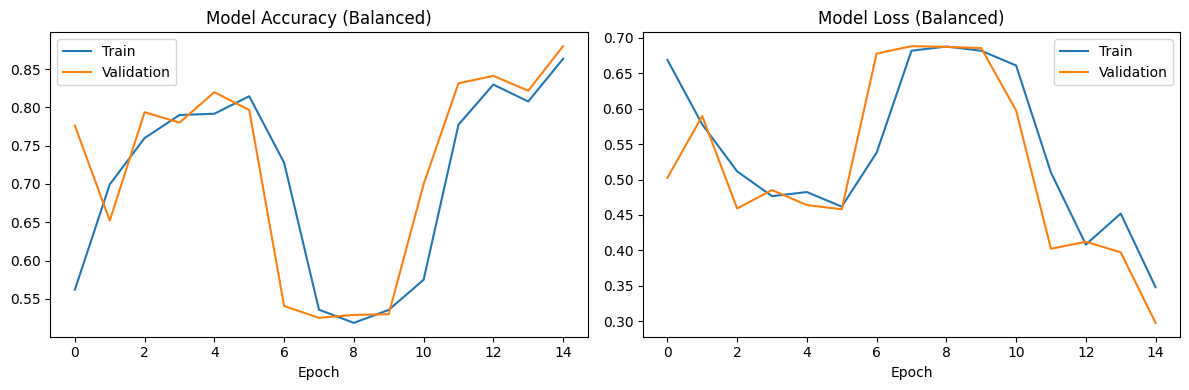

In [22]:
# Save model !!
model3.save('audio_deepfake_detector.h5')
print("Model saved.")

# Final training plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history3.history['accuracy'], label='Train')
axes[0].plot(history3.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy (Balanced)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history3.history['loss'], label='Train')
axes[1].plot(history3.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss (Balanced)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history_balanced.png', dpi=150)
plt.show()